In [1]:
import os
import matplotlib.pyplot as plt
import phonlab as phon

from kalpy.data import Segment
from kalpy.utterance import Utterance
from kalpy.models import AcousticModel
from kalpy.aligner import KalpyAligner

In [2]:

test_directory = os.path.join(os.path.dirname(os.path.abspath("")), "tests", "data")
acoustic_model_directory = os.path.join(test_directory, "acoustic_models", "sat")
dictionary_path = os.path.join(test_directory, "dictionaries", "test_mfa.txt")
wav_path = os.path.join(test_directory, "wav", "mfa_michael.flac")

In [3]:
am = AcousticModel(acoustic_model_directory)
lc = am.lexicon_compiler
lc.load_pronunciations(dictionary_path)
aligner = KalpyAligner(am, lc)
seg = Segment(wav_path)
utterance = Utterance(seg, "montreal forced aligner")
ctm = aligner.align_utterance(utterance)

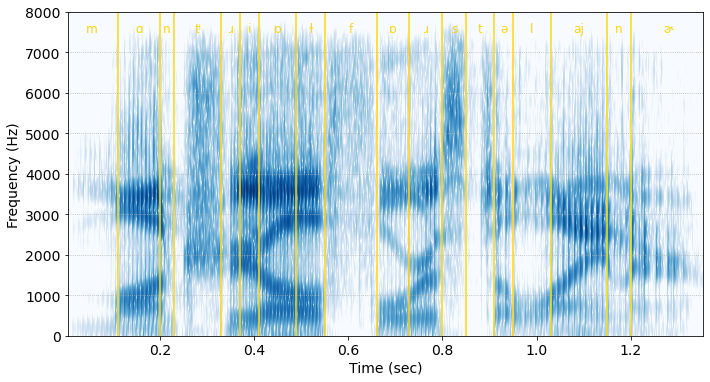

In [4]:
ret = phon.sgram(seg.wave,16000,cmap="Blues")
boundaries = ctm.phone_boundaries
ret[0].vlines(boundaries, 0, 8000,colors='#FFD60A')
for label, midpoint in ctm.labelled_midpoints:
    ret[0].annotate(label, (midpoint, 7500), color='#FFD60A', ha="center", fontsize="large")

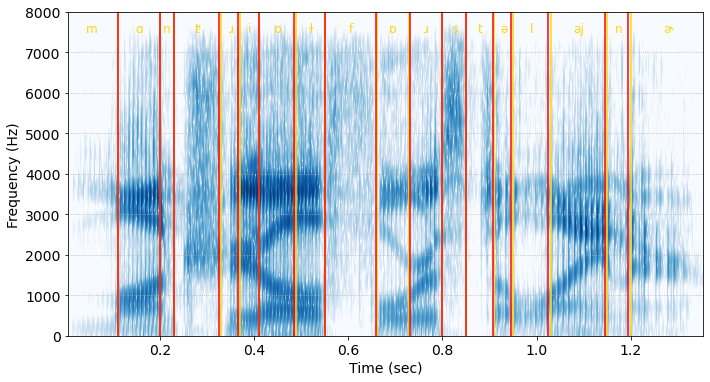

In [5]:
fine_tuned_ctm = aligner.fine_tune_alignments(utterance)
ret = phon.sgram(seg.wave,16000,cmap="Blues")
boundaries = ctm.phone_boundaries
ret[0].vlines(boundaries, 0, 8000,colors='#FFD60A')
boundaries = fine_tuned_ctm.phone_boundaries
ret[0].vlines(boundaries, 0, 8000,colors='red')
for label, midpoint in ctm.labelled_midpoints:
    ret[0].annotate(label, (midpoint, 7500), color='#FFD60A', ha="center", fontsize="large")

In [6]:
labels = ctm.labelled_midpoints
fine_tuned_boundaries = fine_tuned_ctm.phone_boundaries
for i, b in enumerate(ctm.phone_boundaries):
    if b != fine_tuned_boundaries[i]:
        print(f"Fine tuning moved the end of {labels[i][0]} from {b:.3f} to {fine_tuned_boundaries[i]:.3f}" )

Fine tuning moved the end of m from 0.110 to 0.111
Fine tuning moved the end of ɑ from 0.200 to 0.199
Fine tuning moved the end of tʲ from 0.330 to 0.325
Fine tuning moved the end of ɹ from 0.370 to 0.365
Fine tuning moved the end of i from 0.410 to 0.411
Fine tuning moved the end of ɒ from 0.490 to 0.485
Fine tuning moved the end of ɫ from 0.550 to 0.551
Fine tuning moved the end of f from 0.660 to 0.659
Fine tuning moved the end of ɒ from 0.730 to 0.732
Fine tuning moved the end of s from 0.850 to 0.851
Fine tuning moved the end of t from 0.910 to 0.908
Fine tuning moved the end of ə from 0.950 to 0.945
Fine tuning moved the end of l from 1.030 to 1.025
Fine tuning moved the end of aj from 1.150 to 1.146
Fine tuning moved the end of n from 1.200 to 1.195


In [7]:
from _kalpy.matrix import DoubleMatrix, FloatMatrix, FloatSubMatrix, FloatSubVector
from _kalpy.gmm import gmm_interpolate_boundary
from _kalpy.hmm import SplitToPhones

In [8]:
lexicon_compiler = lc
alignment = aligner._align_utterance(utterance)
split = SplitToPhones(am.transition_model, alignment.alignment)
phone_intervals = alignment.generate_ctm(
    am.transition_model,
    lexicon_compiler.phone_table,
    am.frame_shift_seconds,
)
ctm = lexicon_compiler.phones_to_pronunciations(
    alignment.words, phone_intervals, transcription=False, text=utterance.transcript
)
ctm.likelihood = alignment.likelihood
ctm.update_utterance_boundaries(utterance.segment.begin, utterance.segment.end)

In [10]:
boundary_index = 4
boundary = phone_intervals[boundary_index].end
feature_padding = 0.04
feature_segment_begin = max(
    round(
        boundary - feature_padding, 4
    ),
    0,
)
feature_segment_end = min(
    round(boundary + feature_padding, 4),
    utterance.segment.end,
)
previous_phone_offset_window = (phone_intervals[boundary_index].end - phone_intervals[boundary_index].begin) / 2
following_phone_offset_window = (phone_intervals[boundary_index+1].end - phone_intervals[boundary_index+1].begin) / 2
begin_offset = round(max(boundary - previous_phone_offset_window - feature_segment_begin, 0.0), 4)
end_offset = round(min(boundary + following_phone_offset_window - feature_segment_begin, feature_segment_end - feature_segment_begin), 4)
print(phone_intervals[0])
print(f"Boundary: {boundary} ({feature_segment_begin}, {feature_segment_end}): {begin_offset, end_offset}")

<CtmInterval of labeled 'm(31)' from 0.000000 to 0.110000confidence=-46.894726>
Boundary: 0.3700000047683716 (0.33, 0.41): (0.01, 0.07)


In [11]:
seg = Segment(
    utterance.segment.file_path,
    feature_segment_begin,
    feature_segment_end
)
seg_feats = am.generate_features_for_fine_tune(seg, cmvn=None, fmllr_trans=None)
begin_index = int(round(begin_offset * 1000))
end_index = int(round(end_offset * 1000))
sub_matrix = FloatSubMatrix(
    seg_feats, begin_index, end_index - begin_index, 0, seg_feats.NumCols()
)
feats = FloatMatrix(sub_matrix)
print(f"Selected feature frames {begin_index}-{end_index} from {seg_feats.NumRows()} total frames")

Selected feature frames 10-70 from 80 total frames


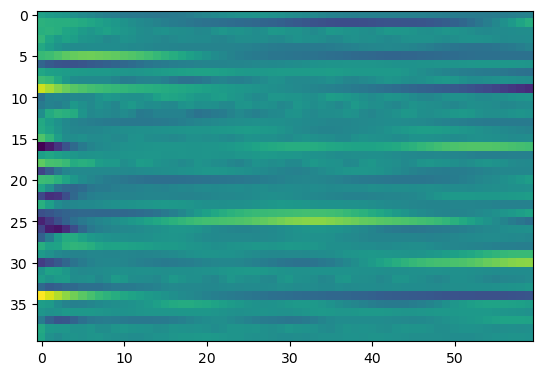

In [19]:
plt.imshow(feats.numpy().T)

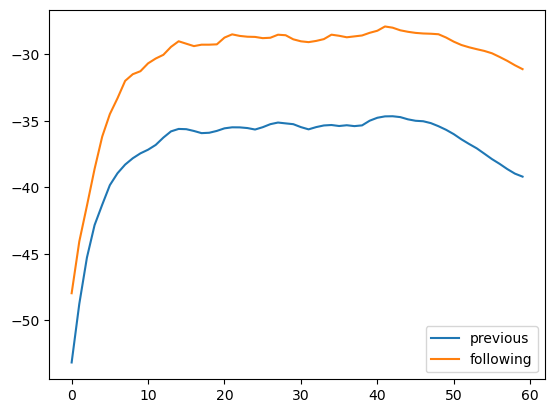

In [20]:
previous_transition_id = split[boundary_index][-1]
following_transition_id = split[boundary_index+1][0]
previous_loglikes = []
following_loglikes = []

previous_pdf_id = am.transition_model.TransitionIdToPdfFast(previous_transition_id)
following_pdf_id = am.transition_model.TransitionIdToPdfFast(following_transition_id)

for i in range(feats.NumRows()):
    feat_row = FloatSubVector(feats, i)
    
    previous_loglikes.append(aligner.ali_aligner.acoustic_model.LogLikelihood(previous_pdf_id, feat_row))
    following_loglikes.append(aligner.ali_aligner.acoustic_model.LogLikelihood(following_pdf_id, feat_row))
plt.plot(previous_loglikes, label="previous")
plt.plot(following_loglikes, label="following")
plt.legend()

0.389
0.37


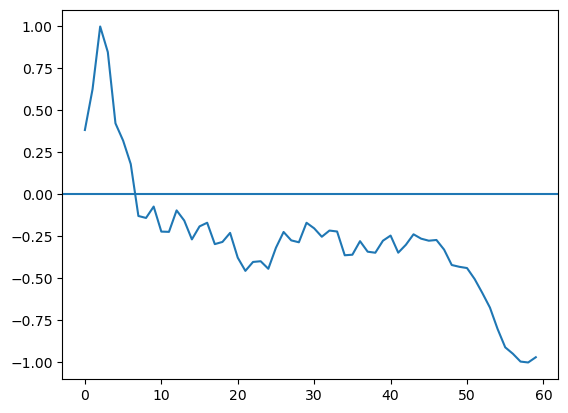

In [21]:
new_boundary_index, ratios = gmm_interpolate_boundary(aligner.ali_aligner.acoustic_model, am.transition_model, feats, previous_transition_id, following_transition_id)
print(round(feature_segment_begin + (new_boundary_index *0.001),3))
print(round(boundary,3))
plt.plot(ratios)
plt.axhline(0)